# Implied Vol Fit

Author: Sebastien Gurrieri, sebgur@gmail.com

This notebook illustrates the implied vol functionalities in the SDevPy library. In its current state, it uses as example the first model in [[Gurrieri 2010]](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1779463).

Named 'TsSvi1' for "Term-Structure SVI 1", this model is essentially the original SVI model by J. Gatheral at each expiry, but where the SVI parameters are parametric functions of time. It is thus a global model for the implied vol surface, calibrated to all options at once. For more details on the properties of this model, see reference above.

In [1]:
import datetime as dt
import numpy as np
from scipy.stats import norm
from platform import python_version
import matplotlib.pyplot as plt
import sdevpy as sd
from sdevpy.analytics import black
from sdevpy.market import eqvolsurface as vsurf
from sdevpy.market.yieldcurve import get_yieldcurve
from sdevpy.market.eqforward import get_forward_curves
from sdevpy.volatility.impliedvol.models.tssvi1 import TsSvi1
from sdevpy.volatility.impliedvol.models.tssvi2 import TsSvi2
from sdevpy.volatility.impliedvol.models.logmix import LogMix
from sdevpy.volatility.impliedvol.impliedvol_calib import TsIvCalibrator
from sdevpy.volatility.localvol.dupire_calib import calib_lv_dupire
from sdevpy.volatility.localvol.black_calib import calib_lv_black
from sdevpy.volatility.localvol.localvol import MatrixLocalVol
from sdevpy.utilities import timegrids
from sdevpy.utilities import dates as dts
from sdevpy.maths.metrics import rmse
from sdevpy.utilities.algos import upper_bound


print("Python version: " + python_version())
print("NumPy version: " + np.__version__)
print("SDevPy version: " + sd.__version__)

Python version: 3.14.0
NumPy version: 2.3.5
SDevPy version: 1.0.5


### Retrieve market data
The SDevPy library has a set of minimalistic market data files containing sample data. Beware that it contains toy data only, to be used strictly for illustration purposes. The data necessary for fitting, which is the expiries, the forwards, the strikes and the volatilities, are all contained in 1 file (per valuation date) and retrieved in an object (dictionary). The user can use the model simply by re-creating that object from their own data.

In [2]:
name = "ABC"
valdate = dt.datetime(2025, 12, 15)

# Retrieve forward curve
fwd_curve = get_forward_curves([name], valdate)[0]

# Retrieve option data
file = vsurf.data_file(name, valdate)
option_data = vsurf.eqvolsurfacedata_from_file(file)
mkt_data = {'option_data': option_data, 'forward_curve': fwd_curve}
print(f"Retrieved market data from file {file}")

# Access data in object
expiries = option_data.expiries
fwds = fwd_curve.value(expiries)
mkt_strikes = option_data.get_strikes(fwd_curve=fwd_curve, to_type='absolute')
mkt_vols = option_data.vols

# Quick check of size consistency
print(f"Number of expiries: {len(expiries)}")
print(f"Number of forwards: {len(fwds)}")
print(f"Number of strike sections: {len(mkt_strikes)}")
print(f"Number of vol sections: {len(mkt_vols)}")
for i in range(len(expiries)):
    print(f"Expiry {i+1} number of strikes/vols: {len(mkt_strikes[i])}/{len(mkt_vols[i])}")

Retrieved market data from file C:\Code\SDev.Python\datasets\marketdata\eqoptions\ABC\20251215-000000.json
Number of expiries: 6
Number of forwards: 6
Number of strike sections: 6
Number of vol sections: 6
Expiry 1 number of strikes/vols: 5/5
Expiry 2 number of strikes/vols: 5/5
Expiry 3 number of strikes/vols: 5/5
Expiry 4 number of strikes/vols: 5/5
Expiry 5 number of strikes/vols: 5/5
Expiry 6 number of strikes/vols: 5/5


In [3]:
# Initialize model
# # iv_surface = LogMix(2)

iv_surface = TsSvi1()

# # Flat on spot with term-structure (compare to BS)
# iv_surface = TsSvi2()
# # v0, vinf, chi, tau_v, alpha, beta, rho0, rhoinf, tau_rho, m0, minf, tau_m, s0, sinf, tau_s
# init_point = [0.32,  0.22, 0.0, 0.7, 0.0, 0.0, 0.0, -0.2, 1.3,  0.001, -0.017,  0.23, 0.000001,
#               2.0, 5.0]
# iv_surface.update_params(init_point)
# iv_surface.base_date = valdate

# iv_surface = LogMix(1)
# init_params = [0.2, 0.2, 0.2, 0.5, 1.0]
# iv_surface.update_params(init_params)
# iv_surface.base_date = valdate

# Calibrate model
calibrator = TsIvCalibrator(iv_surface, {'optimizer': 'SLSQP', 'tol': 1e-6})
calibrator.calibrate(mkt_data)

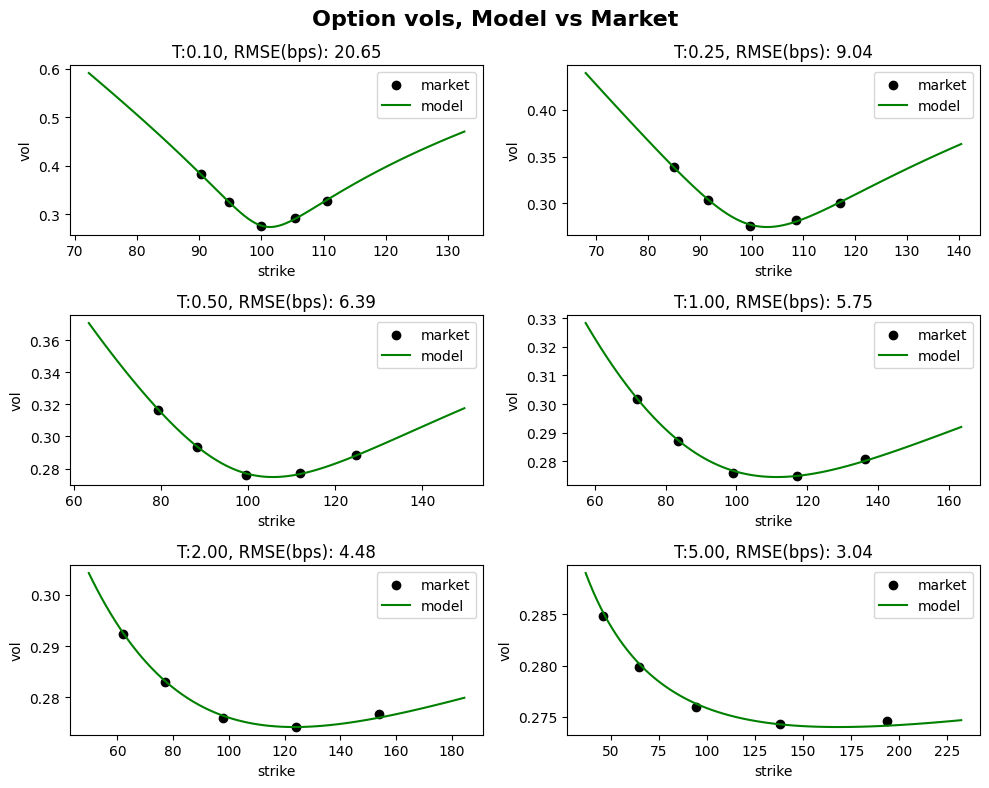

In [4]:
# Estimate model on points and calculate RMSE, plot comparison
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = timegrids.model_time(valdate, expiries[exp_idx])
        fwd = fwds[exp_idx]
        exp_strikes = mkt_strikes[exp_idx]
        min_k, max_k = exp_strikes[0], exp_strikes[-1]
        m_strikes = np.linspace(0.8 * min_k, 1.2 * max_k, 100)
        m_vols = iv_surface.black_volatility(expiry, m_strikes, fwd)
        ax.scatter(exp_strikes, mkt_vols[exp_idx], label="market", color='black')
        ax.plot(m_strikes, m_vols, label="model", color='green')
        model_vols = iv_surface.black_volatility(expiry, exp_strikes, fwd)
        vol_rmse = rmse(mkt_vols[exp_idx], model_vols)
        ax.set_title(f"T:{expiry:.2f}, RMSE(bps): {10000.0 * vol_rmse:,.2f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('vol')
        ax.legend()

fig.suptitle('Option vols, Model vs Market', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Black Calibration

In [ ]:
# Pick expiry to calibrate to
idx = 3
calib_dates = [expiries[idx]]
calib_fwds = np.asarray([fwd_curve.value(expiries[idx])])
calib_strikes = calib_fwds
black_calib = calib_lv_black(iv_surface, calib_dates, calib_strikes, calib_fwds)
black_lv_obj = black_calib['lv']
black_lv = black_lv_obj.vol
print(f"Black LV: {black_lv}")

Black LV: 0.27580754427842


In [4]:
# Calibrate to all expiries (ATM)
calib_dates = expiries
calib_fwds = np.asarray(fwd_curve.value(expiries))
calib_strikes = calib_fwds
print(expiries)
black_calib = calib_lv_black(iv_surface, calib_dates, calib_strikes, calib_fwds)
black_lv_obj = black_calib['lv']
black_lv_tgrid = black_lv_obj.vol_grid
print(f"Black LV: {black_lv_tgrid}")

[datetime.datetime(2026, 1, 20, 0, 0) datetime.datetime(2026, 3, 16, 0, 0)
 datetime.datetime(2026, 6, 15, 0, 0)
 datetime.datetime(2026, 12, 15, 0, 0)
 datetime.datetime(2027, 12, 15, 0, 0)
 datetime.datetime(2030, 12, 15, 0, 0)]
Black LV: [np.float64(0.31427416361817884), np.float64(0.30099564487648744), np.float64(0.2832269962298736), np.float64(0.2594463577169621), np.float64(0.2351336984976488), np.float64(0.22161470736017938)]


### Local Vol Calibration (Dupire)
Now we use the implied volatility surface calibrated to market data in the previous section to derive the corresponding local volatility using the Dupire method.

In [5]:
# Granularity
points_per_year = 25
n_strikes = 100

# Retrieve calibration horizon
tmax = timegrids.model_time(valdate, expiries.max())

# # Temp: give t_grid to check against BS
# lv_calib_dates = [valdate]
# lv_calib_dates.extend(expiries)
# lv_calib_times = timegrids.model_time(valdate, lv_calib_dates)
# print(lv_calib_times)

# Launch Dupire calibration
lv_calib = calib_lv_dupire(iv_surface, points_per_year=25, n_strikes=n_strikes,
                           tmax=tmax)#, t_grid=lv_calib_times)
lv_t = lv_calib['t_grid']
lv_moneyness = lv_calib['moneyness']
lv_matrix = lv_calib['lv_matrix']
lv_obj = lv_calib['lv']
# lv_obj = MatrixLocalVol(lv_t, np.log(lv_moneyness), lv_matrix)
# lv_map = {name: lv_obj}

In [20]:
# Compare Black and Dupire LVs
comp_t = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 3.0]
logm = [-0.5, 0.0, 0.5]
for t in comp_t:
    b = black_lv_obj.value(t, logm)
    d = lv_obj.value(t, logm)
    print(f"<><><><> {t} <><><><>")
    print(f"Black: {b}")
    print(f"Dupire: {d}")

<><><><> 0.01 <><><><>
Black: 0.31427416361817884
Dupire: [0.4867068  0.27585363 0.41129404]
<><><><> 0.05 <><><><>
Black: 0.31427416361817884
Dupire: [0.4867068  0.27585363 0.41129404]
<><><><> 0.1 <><><><>
Black: 0.30099564487648744
Dupire: [0.44874908 0.21652182 0.41122234]
<><><><> 0.25 <><><><>
Black: 0.2832269962298736
Dupire: [0.40188977 0.24035618 0.36601647]
<><><><> 0.5 <><><><>
Black: 0.2594463577169621
Dupire: [0.36240648 0.25468063 0.33301653]
<><><><> 0.75 <><><><>
Black: 0.2594463577169621
Dupire: [0.36240648 0.25468063 0.33301653]
<><><><> 1.0 <><><><>
Black: 0.2594463577169621
Dupire: [0.36240648 0.25468063 0.33301653]
<><><><> 1.25 <><><><>
Black: 0.2351336984976488
Dupire: [0.31829074 0.26357095 0.29645147]
<><><><> 1.5 <><><><>
Black: 0.2351336984976488
Dupire: [0.31829074 0.26357095 0.29645147]
<><><><> 1.75 <><><><>
Black: 0.2351336984976488
Dupire: [0.31829074 0.26357095 0.29645147]
<><><><> 2.0 <><><><>
Black: 0.2351336984976488
Dupire: [0.31829074 0.26357095 0.

In [7]:
# Define 6 expiries to inspect the model (do not have to be the market's)
plot_tenors = ['1m', '3m', '6m', '9m', '1y', '2y']
plot_dates = [dts.advance(valdate, tenor) for tenor in plot_tenors]
# plot_dates = expiries
plot_t = timegrids.model_time(valdate, plot_dates)

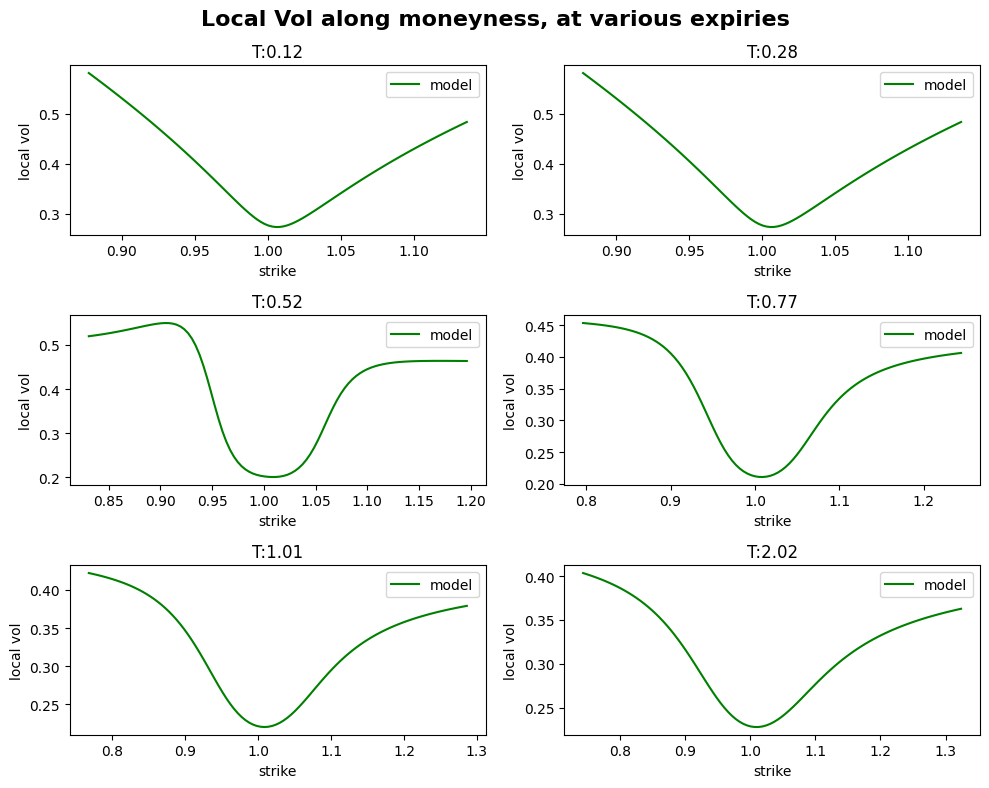

In [8]:
# View the LV along the strike at several expiries
t_idx = [upper_bound(lv_t, tp) for tp in plot_t]
plot_lv_t = lv_t[t_idx]

n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = plot_lv_t[exp_idx]
        ax.plot(lv_moneyness[exp_idx], lv_matrix[exp_idx], label="model", color='green')
        ax.set_title(f"T:{expiry:.2f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('local vol')
        ax.legend()

fig.suptitle('Local Vol along moneyness, at various expiries', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

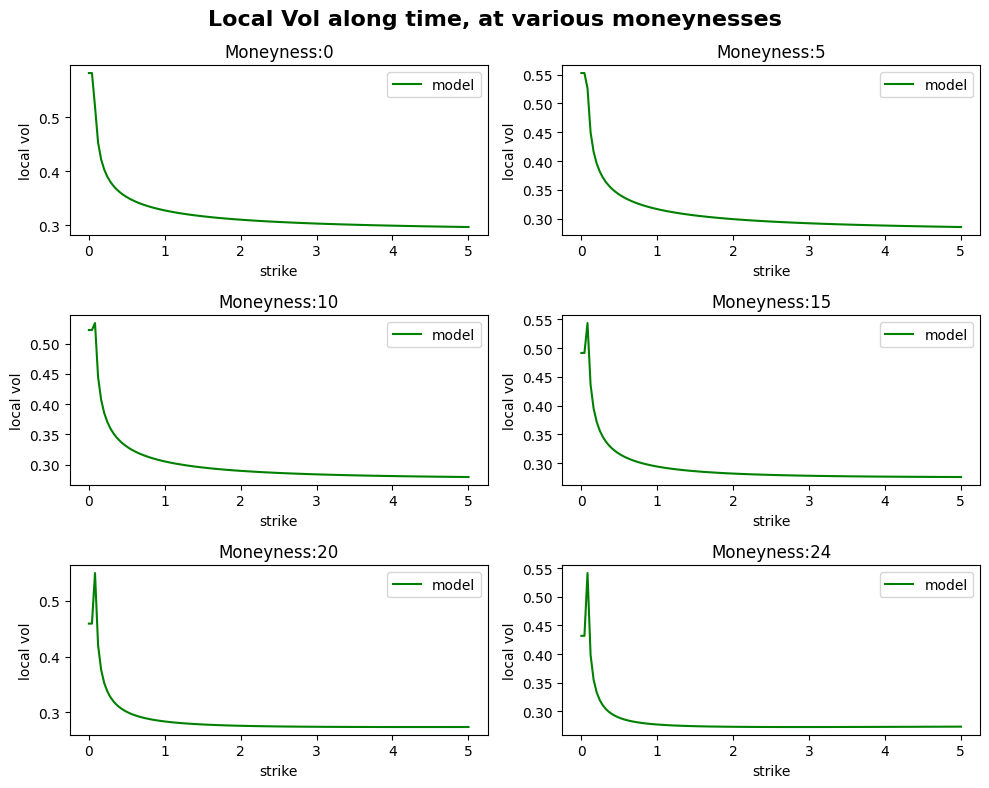

In [9]:
# View LV along the expiry at several moneynesses
m_idx = [0, 5, 10, 15, 20, 24]
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        k_idx = n_cols * i + j
        k_idx = m_idx[k_idx]
        lv_ = [lv_matrix[tidx][k_idx] for tidx in range(len(lv_t))]
        ax.plot(lv_t, lv_, label="model", color='green')
        ax.set_title(f"Moneyness:{k_idx}")
        ax.set_xlabel('strike')
        ax.set_ylabel('local vol')
        ax.legend()

fig.suptitle('Local Vol along time, at various moneynesses', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### Compare MC prices to IV model

In [11]:
# At the 6 expiries chosen to look at the model, we calculate a range of
# strikes within certain reasonable percentiles of the distribution.
n_strikes = 10
lw_p = 0.05
up_p = 1.0 - lw_p
percentiles = np.linspace(lw_p, up_p, n_strikes)
n_quantiles = norm.ppf(percentiles)
plot_fwds, plot_strikes, plot_mod_prices, plot_mod_ivs = [], [], [], []
for date, time in zip(plot_dates, plot_t, strict=True):
    fwd = fwd_curve.value(date)
    atm = iv_surface.black_volatility(time, fwd, fwd)
    stdev = atm * np.sqrt(time)
    strikes = fwd * np.exp(-0.5 * stdev * stdev + stdev * n_quantiles)
    plot_fwds.append(fwd)
    plot_strikes.append(strikes)
    plot_mod_prices.append(iv_surface.forward_price(time, strikes, True, fwd))
    plot_mod_ivs.append(iv_surface.black_volatility(time, strikes, fwd))

In [12]:
from sdevpy.utilities import book as bk
from sdevpy.montecarlo.payoffs.vanillas import make_vanilla_option
from sdevpy.montecarlo.payoffs import cashflows as cfl
from sdevpy.montecarlo.payoffs.basic import Trade, Instrument
from sdevpy.montecarlo.mcpricer import price_book

n_paths = 40000
n_steps = 250
# lv_map = {name: black_lv_obj}
lv_map = {name: lv_obj}

# Create portfolio
option_type = 'Call'
trades = []
for exp_idx, expiry in enumerate(plot_dates):
    exp_strikes = plot_strikes[exp_idx]
    for strike in exp_strikes:
        index = make_vanilla_option(name, strike, option_type, expiry)
        cf = cfl.Cashflow(index, expiry)
        trades.append(Trade(Instrument(cashflow_legs=[[cf]])))

# Create book
book = bk.Book()
book.add_trades(trades)

# Price book
mc_price = price_book(valdate, book, constr_type='brownianbridge', rng_type='sobol',
                      n_paths=n_paths, n_timesteps=n_steps, lv_map=lv_map)

# Gather results per expiry
disc_curve = get_yieldcurve(book.csa_curve_id, valdate)
mc_prices, mc_ivs = [], []
count = 0
for i in range(len(plot_dates)):
    expiry = plot_t[i]
    fwd = plot_fwds[i]
    # Calculate discount factor to forward MC prices
    disc = disc_curve.discount(plot_dates[i])

    # Collect prices and calculate MC IVs
    exp_mc_prices, exp_mc_ivs = [], []
    exp_strikes = plot_strikes[i]
    for j in range(len(exp_strikes)):
        fwd_price = mc_price['pv'][count] / disc
        strike = exp_strikes[j]
        try:
            iv = black.implied_vol(expiry, strike, True, fwd, fwd_price)
        except Exception:
            iv = np.nan
        exp_mc_prices.append(fwd_price)
        exp_mc_ivs.append(iv)
        count += 1

    mc_prices.append(exp_mc_prices)
    mc_ivs.append(exp_mc_ivs)

print(f"MC prices: {mc_prices}")
print(f"MC IVs: {mc_ivs}")

Runtime(Generate spot paths): 3.2s
Runtime(Interpolate to event grid): 0.0s
Runtime(Payoff calculation): 0.1s
MC prices: [[np.float64(13.292870507196017), np.float64(9.438589677200628), np.float64(7.1856558298410524), np.float64(5.464824081258518), np.float64(4.075022971907106), np.float64(2.9784661075257595), np.float64(2.1453245064589583), np.float64(1.5302408736267303), np.float64(1.0298755747768893), np.float64(0.5108307597598614)], [np.float64(21.68682265389312), np.float64(15.5189793986367), np.float64(11.896353211446336), np.float64(9.15448121327633), np.float64(6.934057923559002), np.float64(5.118980449211863), np.float64(3.6599999615707275), np.float64(2.4970060059070516), np.float64(1.5541753219286272), np.float64(0.6951095689075341)], [np.float64(29.711947358510532), np.float64(21.59483717904866), np.float64(16.761156311325973), np.float64(13.085818227025992), np.float64(10.07649622652536), np.float64(7.555182885379825), np.float64(5.430122046858151), np.float64(3.6483990226

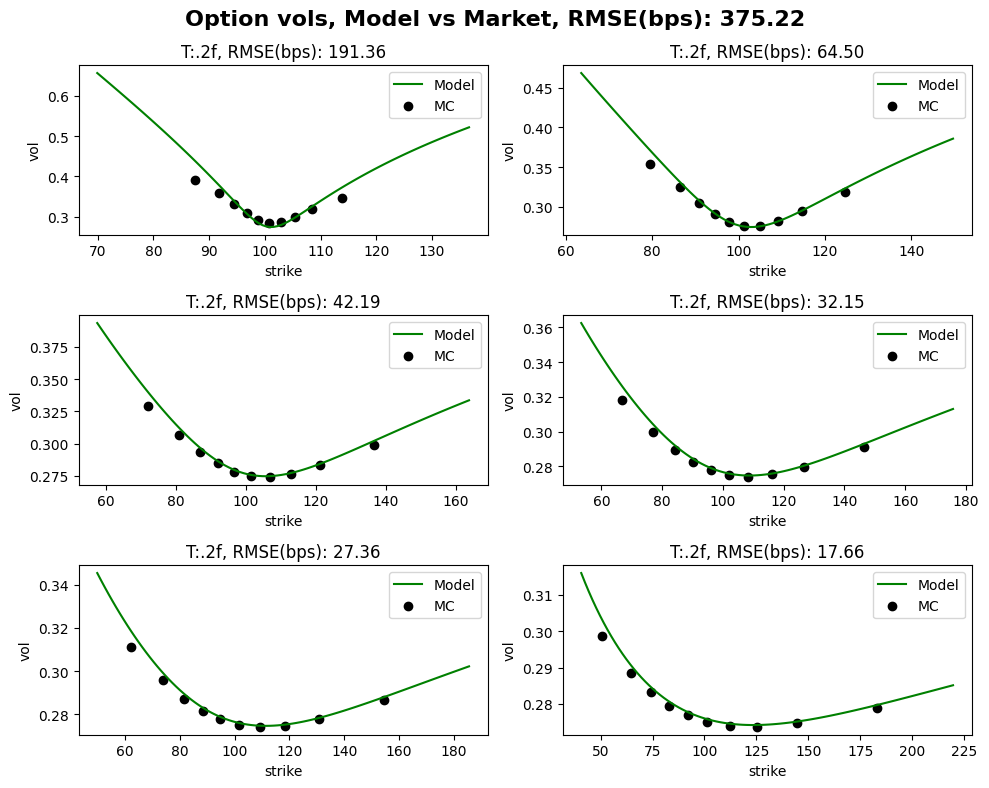

In [13]:
# Plot
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
total_rmse = 0.0
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = plot_dates[exp_idx]
        t = plot_t[exp_idx]
        fwd = plot_fwds[exp_idx]
        exp_strikes = plot_strikes[exp_idx]
        min_k, max_k = exp_strikes[0], exp_strikes[-1]
        mod_strikes = np.linspace(0.8 * min_k, 1.2 * max_k, 100)
        mod_vols = iv_surface.black_volatility(t, mod_strikes, fwd)
        ax.plot(mod_strikes, mod_vols, label="Model", color='green')
        ax.scatter(exp_strikes, mc_ivs[exp_idx], label="MC", color='black')
        plot_mod_ivs = iv_surface.black_volatility(t, exp_strikes, fwd)
        vol_rmse = rmse(mc_ivs[exp_idx], plot_mod_ivs)
        total_rmse += vol_rmse
        ax.set_title(f"T:{expiry:.2f}, RMSE(bps): {10000.0 * vol_rmse:,.2f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('vol')
        ax.legend()

fig.suptitle(f'Option vols, Model vs Market, RMSE(bps): {10000.0 * total_rmse:,.2f}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Compare against PDE prices